In [36]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import plotly.express as px

In [37]:

import pandas as pd

df = pd.read_csv("SampleSuperstore.csv", encoding="latin1")

df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [38]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [39]:
df.shape

(9994, 13)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [41]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [42]:
df.duplicated().sum()

np.int64(17)

In [43]:
df=df.drop_duplicates()

In [44]:
df["Category"].value_counts()

Category
Office Supplies    6012
Furniture          2118
Technology         1847
Name: count, dtype: int64

In [45]:
df["Sub-Category"].value_counts()

Sub-Category
Binders        1522
Paper          1359
Furnishings     956
Phones          889
Storage         846
Art             795
Accessories     775
Chairs          615
Appliances      466
Labels          363
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64

In [46]:
df["Region"].value_counts()

Region
West       3193
East       2845
Central    2319
South      1620
Name: count, dtype: int64

In [47]:
df["Segment"].value_counts()

Segment
Consumer       5183
Corporate      3015
Home Office    1779
Name: count, dtype: int64

In [48]:
df["Ship Mode"].value_counts()

Ship Mode
Standard Class    5955
Second Class      1943
First Class       1537
Same Day           542
Name: count, dtype: int64

In [49]:
print("Total Sales:", df["Sales"].sum())
print("Total Profit:", df["Profit"].sum())
print("Total Quantity:", df["Quantity"].sum())
print("Average Sales:", df["Sales"].mean())
print("Average Profit:", df["Profit"].mean())

Total Sales: 2296195.5903
Total Profit: 286241.42260000005
Total Quantity: 37820
Average Sales: 230.14890150345792
Average Profit: 28.690129557983365


In [50]:
df.groupby("Category")[["Sales","Profit"]].sum()

,Sales,Profit
Category,,
Furniture,741306.3133,18421.8137
Office Supplies,718735.2440,122364.6608
Technology,836154.0330,145454.9481


In [51]:
df.groupby("Sub-Category")[["Sales","Profit"]].sum().sort_values(by="Sales", ascending=False)

,Sales,Profit
Sub-Category,,
Phones,330007.0540,44515.7306
Chairs,327777.7610,26567.1278
Storage,223843.6080,21278.8264
Tables,206965.5320,-17725.4811
Binders,203409.1690,30228.0003
Machines,189238.6310,3384.7569
Accessories,167380.3180,41936.6357
Copiers,149528.0300,55617.8249
Bookcases,114879.9963,-3472.5560


In [52]:
df.groupby("Region")[["Sales","Profit"]].sum().sort_values(by="Sales", ascending=False)

,Sales,Profit
Region,,
West,725255.6365,108329.8079
East,678435.1960,91506.3092
Central,500782.8528,39655.8752
South,391721.9050,46749.4303


In [53]:
df.groupby("Segment")[["Sales","Profit"]].sum()

,Sales,Profit
Segment,,
Consumer,1.160833e+06,134007.4413
Corporate,7.060701e+05,91954.9798
Home Office,4.292927e+05,60279.0015


In [54]:
df.groupby("State")[["Sales","Profit"]].sum().sort_values(by="Sales", ascending=False).head(10)

,Sales,Profit
State,,
California,457576.2715,76330.7891
New York,310827.1510,74015.4622
Texas,170124.5418,-25750.9833
Washington,138560.8100,33368.2375
Pennsylvania,116496.3620,-15565.4035
Florida,89473.7080,-3399.3017
Illinois,80162.5370,-12601.6500
Ohio,77976.7640,-16959.3178
Michigan,75879.6440,24428.0903


In [55]:
df.groupby("State")[["Sales","Profit"]].sum().sort_values(by="Profit", ascending=False).head(10)

,Sales,Profit
State,,
California,457576.2715,76330.7891
New York,310827.1510,74015.4622
Washington,138560.8100,33368.2375
Michigan,75879.6440,24428.0903
Virginia,70636.7200,18597.9504
Indiana,53555.3600,18382.9363
Georgia,49095.8400,16250.0433
Kentucky,36591.7500,11199.6966
Minnesota,29863.1500,10823.1874


In [56]:
# states that are giving loss 
df.groupby("State")[["Sales","Profit"]].sum().sort_values(by="Profit").head(10)

,Sales,Profit
State,,
Texas,170124.5418,-25750.9833
Ohio,77976.7640,-16959.3178
Pennsylvania,116496.3620,-15565.4035
Illinois,80162.5370,-12601.6500
North Carolina,55603.1640,-7490.9122
Colorado,32108.1180,-6527.8579
Tennessee,30661.8730,-5341.6936
Arizona,35282.0010,-3427.9246
Florida,89473.7080,-3399.3017


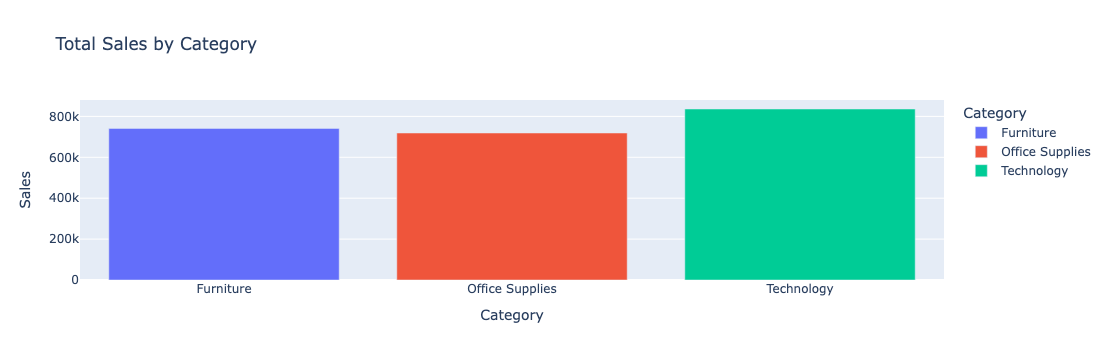

In [61]:
sales_category = df.groupby("Category")["Sales"].sum().reset_index()

fig = px.bar(
    sales_category,
    x="Category",
    y="Sales",
    color="Category",
    title="Total Sales by Category"
)

fig.show()

technology has the highest sales
office supplies has lowest in category

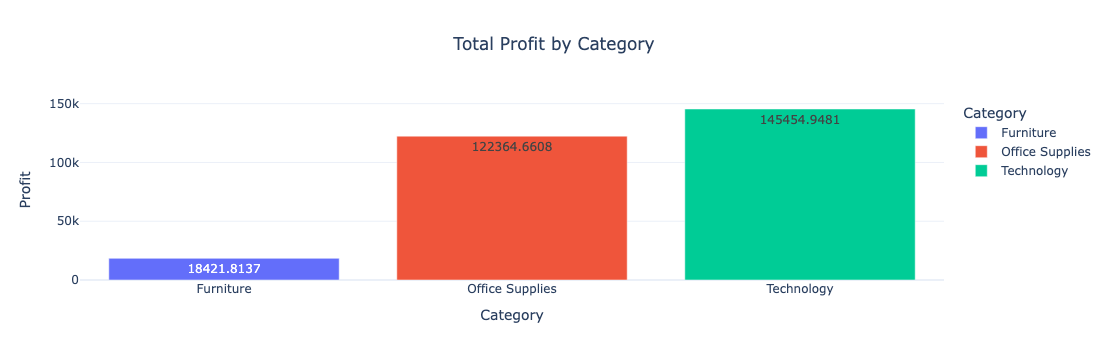

In [63]:
profit_category = df.groupby("Category")["Profit"].sum().reset_index()

fig = px.bar(
    profit_category,
    x="Category",
    y="Profit",
    color="Category",
    text="Profit",
    title="Total Profit by Category"
)

fig.update_layout(template="plotly_white", title_x=0.5)

fig.show()

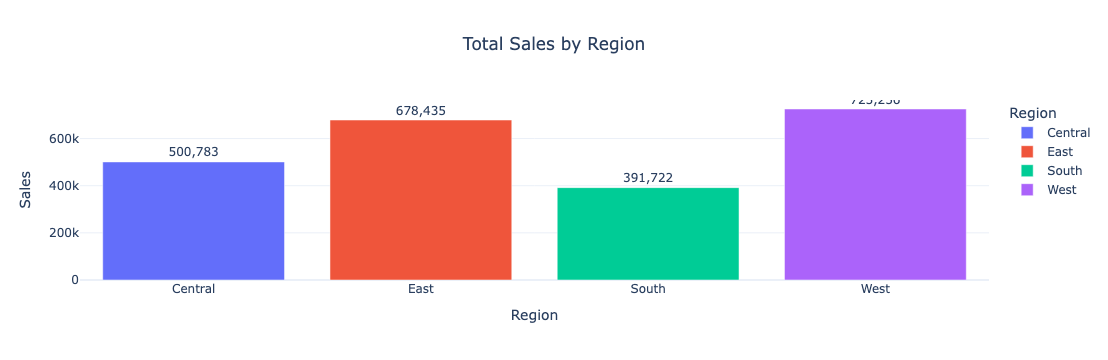

In [64]:
region_sales = df.groupby("Region")["Sales"].sum().reset_index()

fig = px.bar(
    region_sales,
    x="Region",
    y="Sales",
    color="Region",
    text="Sales",
    title="Total Sales by Region"
)

fig.update_traces(texttemplate='%{text:,.0f}', textposition='outside')
fig.update_layout(template="plotly_white", title_x=0.5)

fig.show()

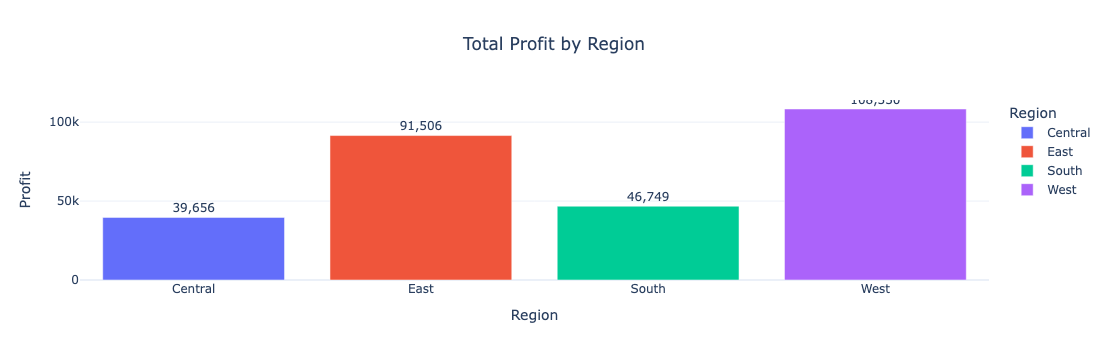

In [66]:
region_profit = df.groupby("Region")["Profit"].sum().reset_index()

fig = px.bar(
    region_profit,
    x="Region",
    y="Profit",
    color="Region",
    text="Profit",
    title="Total Profit by Region"
)

fig.update_traces(texttemplate='%{text:,.0f}', textposition='outside')
fig.update_layout(template="plotly_white", title_x=0.5)

fig.show()

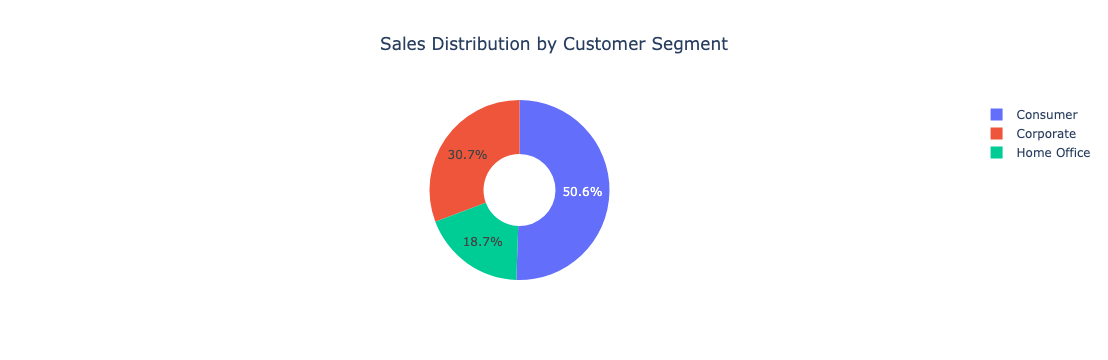

In [65]:
segment_sales = df.groupby("Segment")["Sales"].sum().reset_index()

fig = px.pie(
    segment_sales,
    names="Segment",
    values="Sales",
    title="Sales Distribution by Customer Segment",
    hole=0.4
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5
)

fig.show()

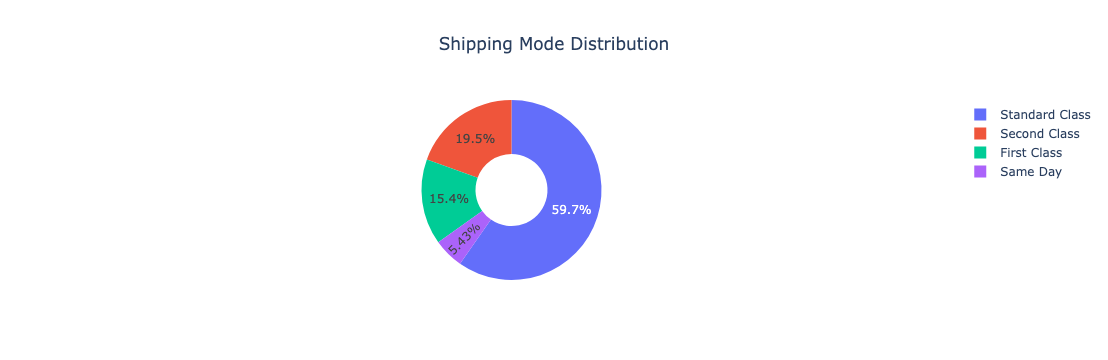

In [67]:
ship = df["Ship Mode"].value_counts().reset_index()
ship.columns = ["Ship Mode", "Count"]

fig = px.pie(
    ship,
    names="Ship Mode",
    values="Count",
    hole=0.4,
    title="Shipping Mode Distribution"
)

fig.update_layout(template="plotly_white", title_x=0.5)

fig.show()

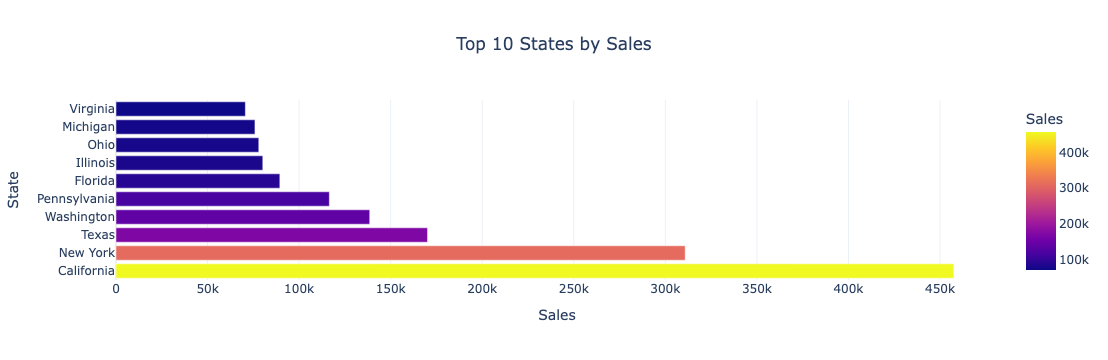

In [68]:
top_states = df.groupby("State")["Sales"].sum().nlargest(10).reset_index()

fig = px.bar(
    top_states,
    x="Sales",
    y="State",
    orientation="h",
    color="Sales",
    title="Top 10 States by Sales"
)

fig.update_layout(template="plotly_white", title_x=0.5)

fig.show()

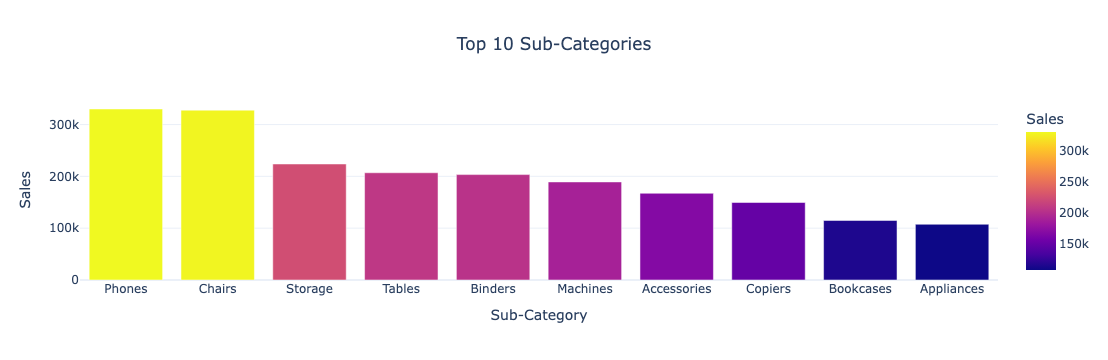

In [69]:
top_sub = df.groupby("Sub-Category")["Sales"].sum().nlargest(10).reset_index()

fig = px.bar(
    top_sub,
    x="Sub-Category",
    y="Sales",
    color="Sales",
    title="Top 10 Sub-Categories"
)

fig.update_layout(template="plotly_white", title_x=0.5)

fig.show()

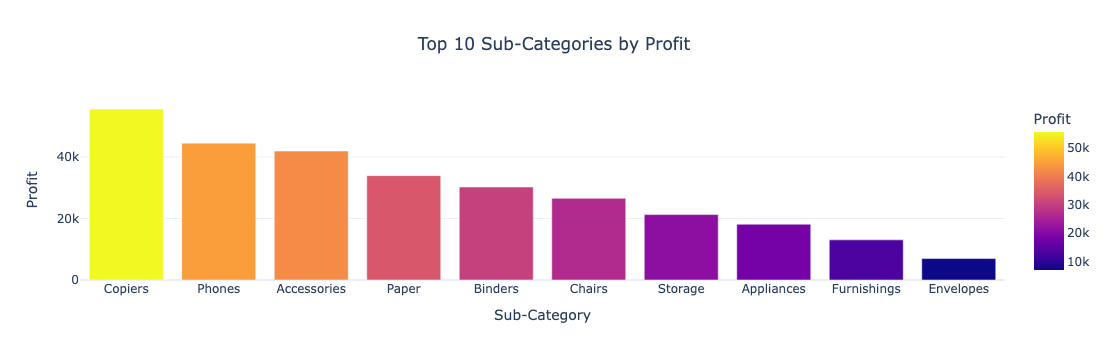

In [70]:
top_profit = df.groupby("Sub-Category")["Profit"].sum().nlargest(10).reset_index()

fig = px.bar(
    top_profit,
    x="Sub-Category",
    y="Profit",
    color="Profit",
    title="Top 10 Sub-Categories by Profit"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5
)

fig.show()

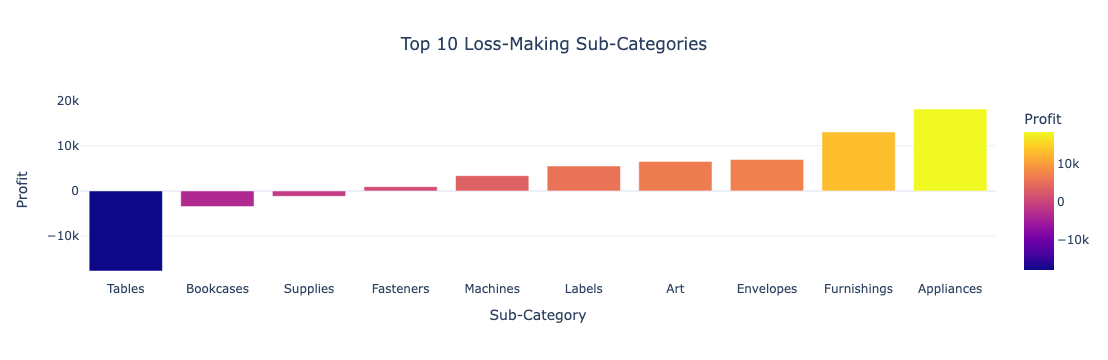

In [71]:
loss_sub = df.groupby("Sub-Category")["Profit"].sum().nsmallest(10).reset_index()

fig = px.bar(
    loss_sub,
    x="Sub-Category",
    y="Profit",
    color="Profit",
    title="Top 10 Loss-Making Sub-Categories"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5
)

fig.show()

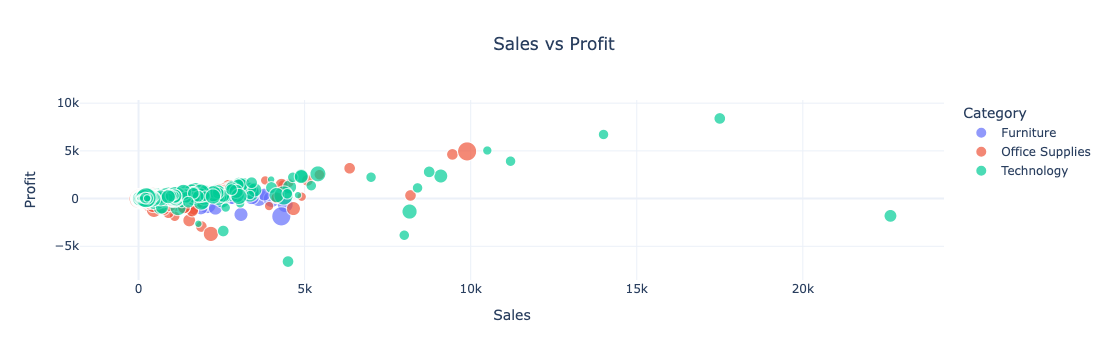

In [72]:
fig = px.scatter(
    df,
    x="Sales",
    y="Profit",
    color="Category",
    size="Quantity",
    hover_data=["Sub-Category"],
    title="Sales vs Profit"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5
)

fig.show()

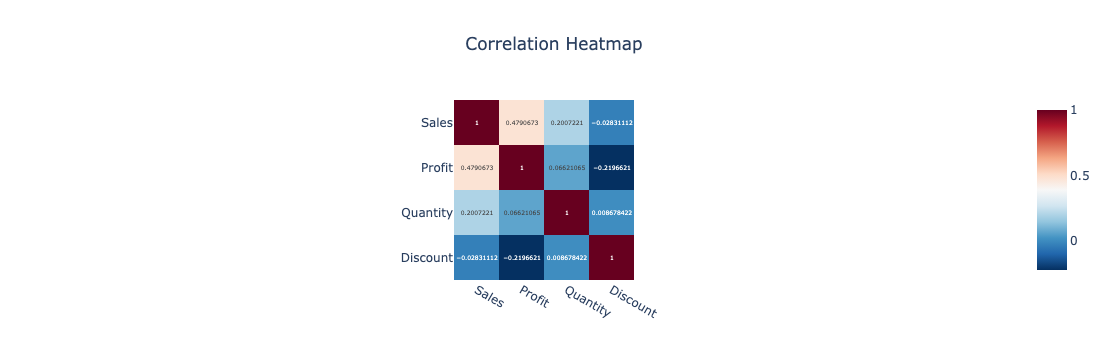

In [74]:
import plotly.express as px

corr = df[["Sales", "Profit", "Quantity", "Discount"]].corr()

fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale="RdBu_r",
    title="Correlation Heatmap"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5
)

fig.show()

In [75]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = len(df)
total_quantity = df["Quantity"].sum()

print("Total Sales :", round(total_sales, 2))
print("Total Profit :", round(total_profit, 2))
print("Total Orders :", total_orders)
print("Total Quantity :", total_quantity)

Total Sales : 2296195.59
Total Profit : 286241.42
Total Orders : 9977
Total Quantity : 37820


In [79]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        "Sales by Category",
        "Profit by Category",
        "Sales by Region",
        "Sales by Segment"
    )
)

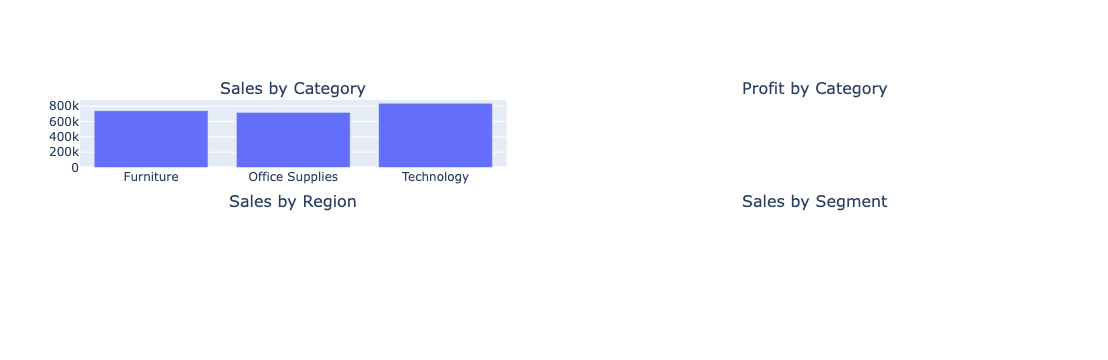

In [80]:
sales_category = df.groupby("Category")["Sales"].sum().reset_index()

fig.add_trace(
    go.Bar(
        x=sales_category["Category"],
        y=sales_category["Sales"],
        name="Sales by Category"
    ),
    row=1,
    col=1
)

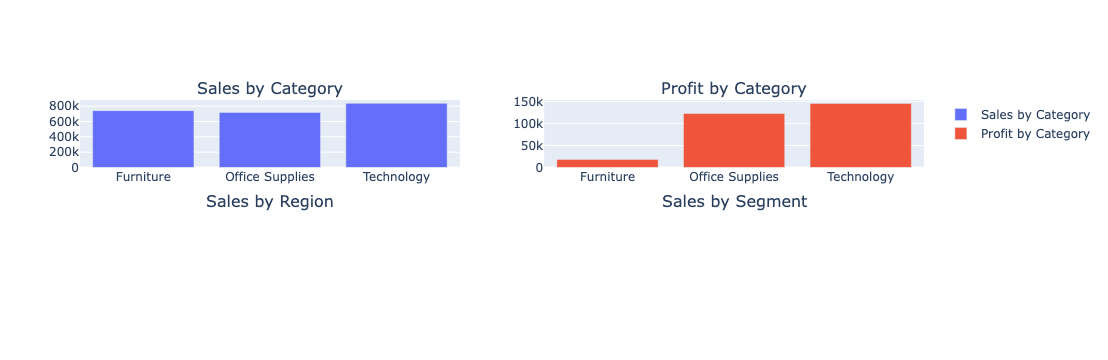

In [81]:
profit_category = df.groupby("Category")["Profit"].sum().reset_index()

fig.add_trace(
    go.Bar(
        x=profit_category["Category"],
        y=profit_category["Profit"],
        name="Profit by Category"
    ),
    row=1,
    col=2
)

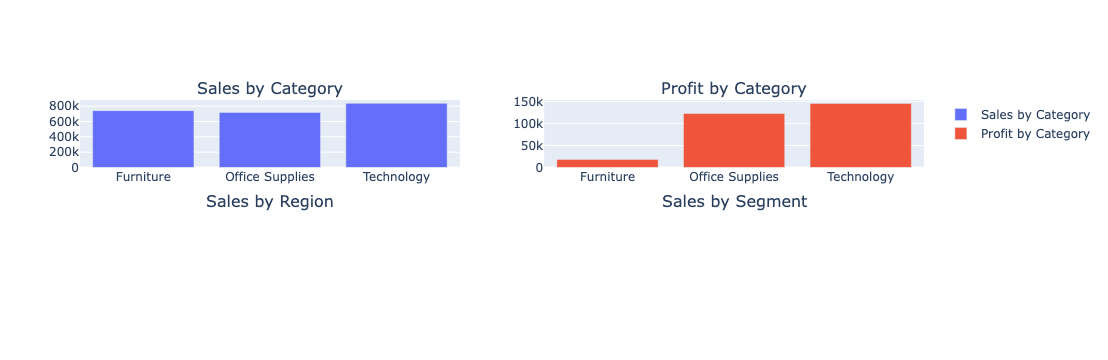

In [82]:
fig.show()

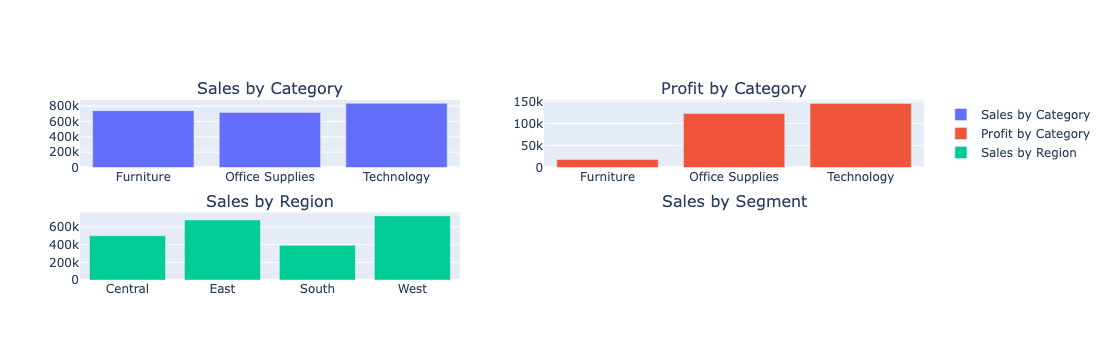

In [83]:
region_sales = df.groupby("Region")["Sales"].sum().reset_index()

fig.add_trace(
    go.Bar(
        x=region_sales["Region"],
        y=region_sales["Sales"],
        name="Sales by Region"
    ),
    row=2,
    col=1
)

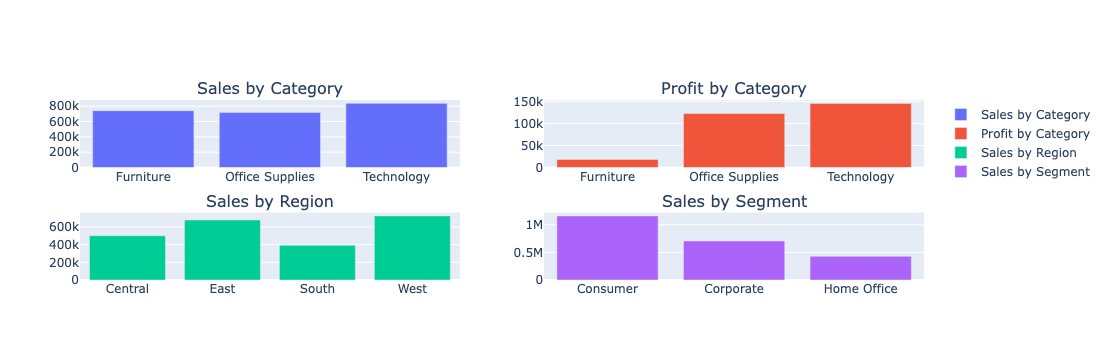

In [84]:
segment_sales = df.groupby("Segment")["Sales"].sum().reset_index()

fig.add_trace(
    go.Bar(
        x=segment_sales["Segment"],
        y=segment_sales["Sales"],
        name="Sales by Segment"
    ),
    row=2,
    col=2
)

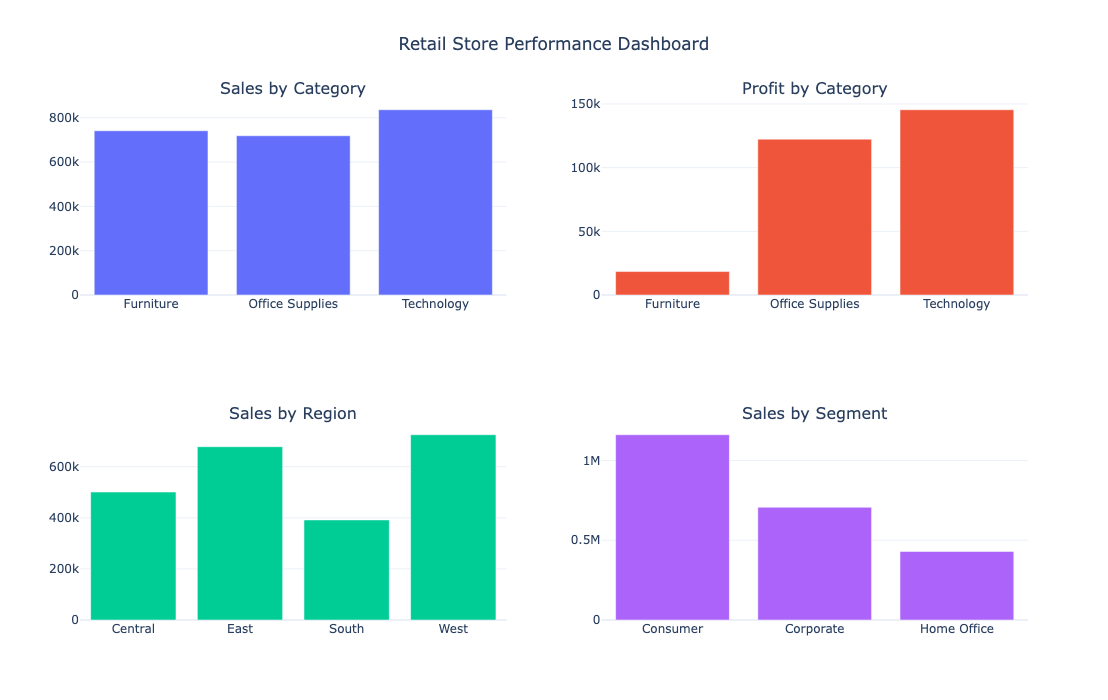

In [85]:
fig.update_layout(
    height=700,
    width=1100,
    title_text="Retail Store Performance Dashboard",
    title_x=0.5,
    template="plotly_white",
    showlegend=False
)

fig.show()